# Question: V-plot
# Author: G Mahendra Reddy
# Enrollment Number : 23114030

In [1]:
# Imports 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from collections import defaultdict

In [2]:
# Initialize a dictionary to count Z = frequency of each (X, Y) pair
counter = defaultdict(int)

# Read the file line by line
with open("mapped.bed", "r") as f:
    for line in f:
        cols = line.strip().split("\t")
        # Convert relevant columns to integers
        start1 = int(cols[2])
        end1 = int(cols[3])
        start2 = int(cols[8])
        end2 = int(cols[9])

        # Compute centers and fragment size
        c1 = (start1 + end1) // 2
        c2 = (start2 + end2) // 2
        x = c2 - c1
        y = end2 - start2

        # Increment count of this (x, y) pair
        counter[(x, y)] += 1



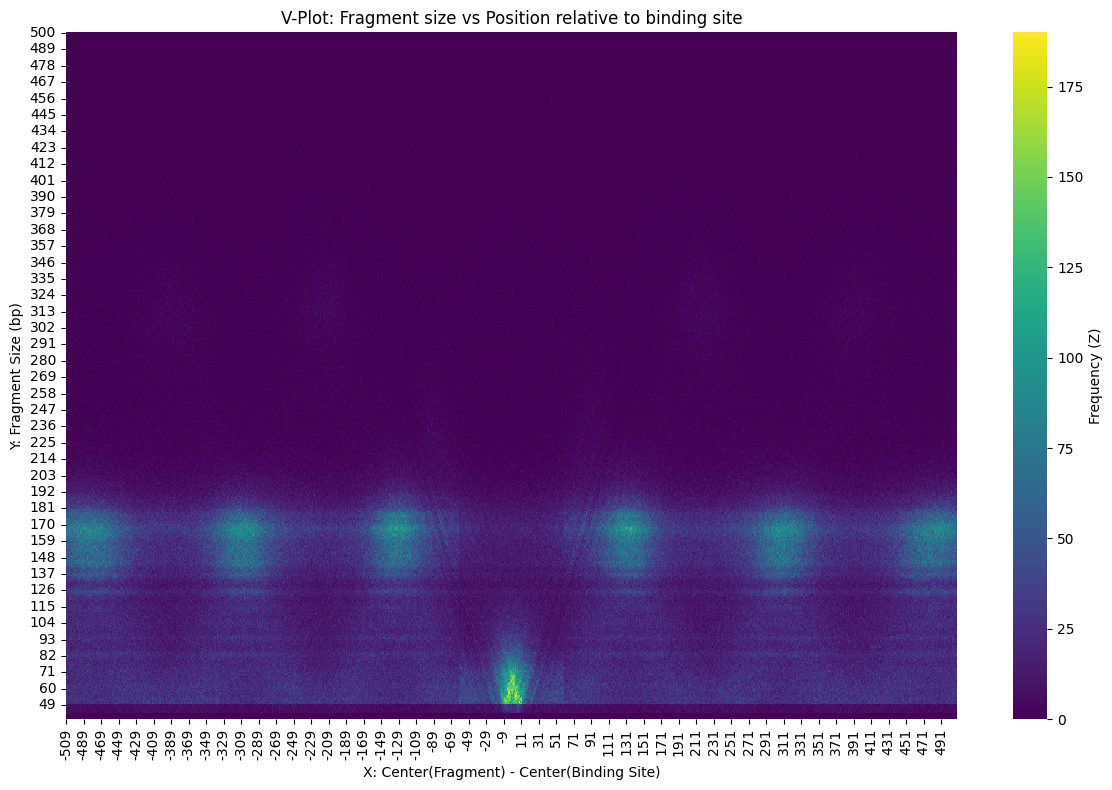

In [3]:
# Convert to DataFrame for plotting
data = pd.DataFrame(
    [(x, y, z) for (x, y), z in counter.items()],
    columns=["X", "Y", "Z"]
)

# Pivot table to create 2D grid for heatmap
heatmap_data = data.pivot_table(index="Y", columns="X", values="Z", fill_value=0)
heatmap_data = heatmap_data.sort_index(ascending=False)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap="viridis", cbar_kws={'label': 'Frequency (Z)'})
plt.title("V-Plot: Fragment size vs Position relative to binding site")
plt.xlabel("X: Center(Fragment) - Center(Binding Site)")
plt.ylabel("Y: Fragment Size (bp)")
plt.tight_layout()
plt.show()
